# Random Forest

The code below trains a Random Forest classifier using the best hyperparameters identified through a randomized search. 
The best classifier is then evaluated on the test dataset, followed by a discussion of the results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import ensemble, metrics
from sklearn.model_selection import RandomizedSearchCV

In [2]:
train = pd.read_csv('train_processed.csv')
validation = pd.read_csv('validation_processed.csv')
test = pd.read_csv('test_processed.csv')
train.head(2)

,loan_status,loan_amnt,int_rate,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,...,verif__Not Verified,verif__Source Verified,verif__Verified,purpose__consumer_needs,purpose__credit_card,purpose__debt_consolidation,purpose__home_improvement,purpose__other,list__f,list__w
0,0,25000.0,19.20,11.938200,6.39,9.0,0,10.150348,49.6,21.0,...,0,0,1,0,0,1,0,0,1,0
1,1,5000.0,13.67,10.686567,6.23,14.0,1,8.822470,45.8,38.0,...,1,0,0,1,0,0,0,0,0,1


In [3]:
# Features and Label
# for train 
y_train = train['loan_status']
X_train = train.iloc[:, 1:]

# for validation
y_val = validation['loan_status']
X_val = validation.iloc[:, 1:]

# for test
y_test = test['loan_status']
X_test = test.iloc[:, 1:]

## Model Training

To identify the best set of hyperparameters I apply the  RandomizedSearchCV() from sklearn.model_selection as my runtime does not allow to counduct the full Grid search
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html

In [4]:
estimator = ensemble.RandomForestClassifier(class_weight='balanced', random_state=42, bootstrap=True, n_jobs=-1)

param = {
    'n_estimators': [200, 300, 500],
    'max_depth': [8, 20, 30, 40],
    'min_samples_leaf': [5, 10, 25, 50, 100],
    'max_features': [0.15, 0.25, 0.333, 0.4, 'sqrt'],
    'criterion': ['gini', 'entropy']
}

In [5]:
search = RandomizedSearchCV(estimator=estimator, param_distributions=param, n_iter=40,
    scoring='f1', cv=3, verbose=2, random_state=42, n_jobs=-1)

search.fit(X_train, y_train)

Fitting 3 folds for each of 40 candidates, totalling 120 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'criterion': ['gini', 'entropy'], 'max_depth': [8, 20, ...], 'max_features': [0.15, 0.25, ...], 'min_samples_leaf': [5, 10, ...], ...}"
,n_iter,40
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [9]:
print('\nBest Hyperparameters:')
print(search.best_params_, '\n')
print(search.best_estimator_, '\n')


Best Hyperparameters:
{'n_estimators': 300, 'min_samples_leaf': 50, 'max_features': 0.333, 'max_depth': 40, 'criterion': 'entropy'} 

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=40, max_features=0.333, min_samples_leaf=50,
                       n_estimators=300, n_jobs=-1, random_state=42) 



Hm the optimal set of parameters looks interesting. The trees are quite deep (max_depth) - 40, but the complexity regularized by the leaf size - minimum 50

In [22]:
# I copy the parameters from search.best_estimator_ because
# I do not want to run the parameters search each time when open a file
estimator_best = ensemble.RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=40, max_features=0.33, min_samples_leaf=50,
                       min_samples_split=25, n_estimators=500, n_jobs=-1,
                       random_state=42)

estimator_best.fit(X_train, y_train)

,n_estimators,500
,criterion,'entropy'
,max_depth,40
,min_samples_split,25
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,0.33
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
feature_importance = pd.DataFrame({'Feature': X_val.columns, 'Importance': estimator_best.feature_importances_})
feature_importance.sort_values('Importance', ascending=False).head(10)

,Feature,Importance
1,int_rate,0.304077
3,dti,0.107998
2,annual_inc,0.071909
12,term__ 36 months,0.063511
7,revol_util,0.062551
6,revol_bal,0.059934
11,delta_issue_earliest,0.055257
0,loan_amnt,0.054889
13,term__ 60 months,0.052371
8,total_acc,0.037137


The classifier extracts most of its predictive power from features with clear economic meaning, including *interest rate*, *DTI*, *annual income*, *revolving utilisation*, *revolving balance*, *loan amount* and *time delta*. Among the strongest predictors, only *term* is categorical. The most important feature is int_rate, which is not a borrower characteristic but a LoanTap parameter that already embeds the lender's risk assessment. This is therefore an expected result

## Model Validation

In [24]:
y_train_pred = estimator_best.predict(X_train)
y_val_pred = estimator_best.predict(X_val)

print('Train Confusion Matrix: \n', metrics.confusion_matrix(y_train, y_train_pred), '\n')
print('Train Recall:', round(metrics.recall_score(y_train, y_train_pred), 3))
print('Train Precision:', round(metrics.precision_score(y_train, y_train_pred), 3), '\n')
print('Validation Confusion Matrix: \n', metrics.confusion_matrix(y_val, y_val_pred), '\n')
print('Validation Recall:', round(metrics.recall_score(y_val, y_val_pred), 3))
print('Validation Precision:', round(metrics.precision_score(y_val, y_val_pred), 3), '\n')

print('F1 score train:', round(metrics.f1_score(y_train, y_train_pred), 3))
print('F1 score validation:', round(metrics.f1_score(y_val, y_val_pred), 3))

Train Confusion Matrix: 
 [[138547  52907]
 [ 13907  33181]] 

Train Recall: 0.705
Train Precision: 0.385 

Validation Confusion Matrix: 
 [[28813 12213]
 [ 4091  5999]] 

Validation Recall: 0.595
Validation Precision: 0.329 

F1 score train: 0.498
F1 score validation: 0.424


The model generalises reasonably well; however, it delivers only a marginal improvement over Logistic Regression and the Decision Tree. Recall decreases from 63.2% in the Logistic Regression model to 59.5% in the Random Forest model, meaning that the classifier identifies slightly fewer defaulters. On the other hand, it achieves higher precision, indicating that a greater proportion of predicted defaults are true defaults, which results in a slightly higher overall F1 score

In [25]:
y_val_score = estimator_best.predict_proba(X_val)[:, 1]
thresholds = np.arange(0.01, 1, 0.01)

best_f1 = 0
best_threshold = 0

for t in thresholds:
    pred = (y_val_score >= t).astype(int)

    f1 = metrics.f1_score(y_val, pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print('The best Classification Threshold:', round(best_threshold, 3))
print('The best F1 score:', round(best_f1, 3))

The best Classification Threshold: 0.47
The best F1 score: 0.426


The best classification threshold is **0.47** slightly different from the Logistic Regression and Decision Tree

# Model Testing

In [27]:
# I use the initial model and apply the slightly adjusted threshold 0.47
y_test_score = estimator_best.predict_proba(X_test)[:,1]
y_test_pred = (y_test_score >= 0.47).astype(int)

In [28]:
print('Test Confusion Matrix: \n', metrics.confusion_matrix(y_test, y_test_pred), '\n')
print('Test Recall:', round(metrics.recall_score(y_test, y_test_pred), 3))
print('Test Precision:', round(metrics.precision_score(y_test, y_test_pred), 3), '\n')
print('F1 score test:', round(metrics.f1_score(y_test, y_test_pred), 3))

Test Confusion Matrix: 
 [[26446 14581]
 [ 3405  6685]] 

Test Recall: 0.663
Test Precision: 0.314 

F1 score test: 0.426


Actually on the test dataset Recall is already 66.3% which is a slight improvement comparing to the Logistic Regression model

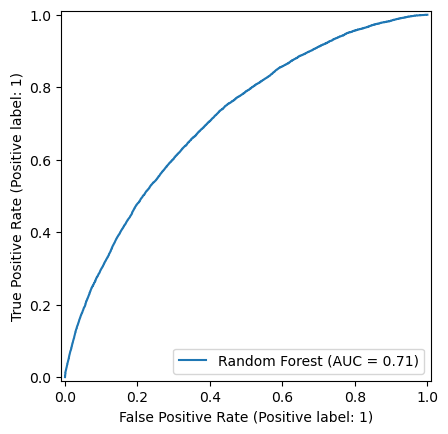

In [29]:
metrics.RocCurveDisplay.from_predictions(y_test, y_test_score, name='Random Forest')
plt.show()

## Conclusion

The Random Forest model achieved an **F1 score** of **0.426** with a **recall** of **66.3%**, representing only a marginal improvement over the Logistic Regression model. The ensemble approach did not uncover substantially stronger non-linear patterns in the data, suggesting that much of the available predictive signal is already captured by simpler relationships. The next step is to experiment with XGBoost, which often performs better on tabular datasets by modelling complex non-linear interactions more effectively than Random Forest.

**Top Predictors:**

| Feature | Importance | 
|:-----------|:------------:|
| int_rate   |  0.304077   | 
| dti     |  0.107998 | 
| annual_inc|0.071909|
| term__ 36 months |0.063511|
| revol_util		 |0.062551|

**Summary of the Test Metrics:**

| Metrics | Model Performance | 
|:-----------|:------------:|
| F1 Score   |  0.426   | 
| Precision        |  0.314 | 
| Recall|0.663|
| AUC |0.71|